# 異常音の異常検知を体験

In [16]:
import sys

In [17]:
sys.executable

'/Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/.venv/bin/python'

# 異常音の異常検知を体験
- ToyADMOS の **ToyCar** データを使って、機械の音から異常を見つける流れを体験

## 今回は次の 3 つの方法の比較
- - **PCA**：正常データをうまく表せない音を異常とみなす
- - **kNN**：正常データから遠い音を異常とみなす
- - **One-Class SVM**：正常データのまとまりから外れる音を異常とみなす



- # データセット
-  **ToyADMOS** 
   -  小型機械の動作音を集めた、異常音検知の学習用データセット
- データセット配布ページ：Zenodomm
- 参考 GitHub：ToyADMOS-dataset
- 論文：Koizumi ら, *ToyADMOS: A Dataset of Miniature-Machine Operating Sounds for Anomalous Sound -etection*, WASPAA 2019
- このノートブックでは、**ToyCar** の一部だけを使用


In [18]:
# !pip -q install librosa soundfile scikit-learn tqdm

import glob
import os
import random

import librosa
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import (average_precision_score, classification_report,
                             roc_auc_score)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

In [19]:
from pathlib import Path

# ============================================================
# ローカルデータの場所
# ============================================================

# 現在地：lecture_slides/data/hazelnut
# 使用データ：lecture_slides/data/soundData
# BASE_DIR = Path.cwd().parent / "soundData"
BASE_DIR = Path.cwd() / "soundData"

TRAIN_DIR = BASE_DIR / "ToyCar" / "train"
TEST_DIR = BASE_DIR / "ToyCar" / "test"

print("BASE_DIR:", BASE_DIR)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)

    # try:
    #     # 通常の .py ファイルとして実行した場合
    #     BASE_DIR = Path(__file__).resolve().parent
    # except NameError:
    #     # Jupyter / VS Code Interactive Windowの場合
    #     BASE_DIR = Path.cwd()

    # print("BASE_DIR:", BASE_DIR)

    # TRAIN_DIR = BASE_DIR / "ToyCar" / "train"
    # TEST_DIR = BASE_DIR / "ToyCar" / "test"

# フォルダが正しく見つかるか確認
if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"学習データが見つかりません: {TRAIN_DIR}")

if not TEST_DIR.exists():
    raise FileNotFoundError(f"テストデータが見つかりません: {TEST_DIR}")

print("データフォルダ:", BASE_DIR)
print("学習フォルダ:", TRAIN_DIR)
print("テストフォルダ:", TEST_DIR)


# %% [markdown]
# # 3. 使用する機械IDを決める
#
# 講義では、まず **id_04** の音声だけを使用
#
# - 学習データ：正常音のみ
# - テストデータ：正常音と異常音


TARGET_ID = "id_04"

train_files = sorted(
    str(path) for path in TRAIN_DIR.glob(f"normal_{TARGET_ID}_*.wav")
)

test_normal_files = sorted(
    str(path) for path in TEST_DIR.glob(f"normal_{TARGET_ID}_*.wav")
)

test_anomaly_files = sorted(
    str(path) for path in TEST_DIR.glob(f"anomaly_{TARGET_ID}_*.wav")
)

print("train:", len(train_files))
print("test normal:", len(test_normal_files))
print("test anomaly:", len(test_anomaly_files))

# ファイル名を1件ずつ確認
print("\n最初の学習ファイル:")
print(train_files[0] if train_files else "ファイルなし")

print("\n最初の正常テストファイル:")
print(test_normal_files[0] if test_normal_files else "ファイルなし")

print("\n最初の異常テストファイル:")
print(test_anomaly_files[0] if test_anomaly_files else "ファイルなし")

BASE_DIR: /Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/soundData
TRAIN_DIR: /Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/soundData/ToyCar/train
TEST_DIR: /Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/soundData/ToyCar/test
データフォルダ: /Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/soundData
学習フォルダ: /Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/soundData/ToyCar/train
テストフォルダ: /Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/soundData/ToyCar/test
train: 1000
test normal: 350
test anomaly: 265

最初の学習ファイル:
/Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/soundData/ToyCar/train/normal_id_04_00000000.wav

最初の正常テストファイル:
/Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/soundData/ToyCar/test/

In [20]:
def extract_feature(wav_path, sr=16000, n_mels=128, n_fft=1024, hop_length=512):
    y, _ = librosa.load(wav_path, sr=sr, mono=True)

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    )
    logmel = librosa.power_to_db(mel, ref=np.max)

    feat_mean = logmel.mean(axis=1)
    feat_std = logmel.std(axis=1)
    return np.hstack([feat_mean, feat_std]).astype(np.float32)


def load_features(file_list):
    features = []
    for wav_path in tqdm(file_list):
        features.append(extract_feature(wav_path))
    return np.array(features, dtype=np.float32)


In [21]:
X_train = load_features(train_files)
X_test_normal = load_features(test_normal_files)
X_test_anomaly = load_features(test_anomaly_files)

X_test = np.vstack([X_test_normal, X_test_anomaly])
y_test = np.r_[np.zeros(len(X_test_normal), dtype=int),
               np.ones(len(X_test_anomaly), dtype=int)]

print("X_train:", X_train.shape)
print("X_test_normal:", X_test_normal.shape)
print("X_test_anomaly:", X_test_anomaly.shape)
print("X_test:", X_test.shape)



0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
  0%|          | 0/1000 [00:00<?, ?it/s]/Users/jc/Dropbox/dplyr-tutorial-master/GSDS/lecture_jct/lecture_slides/data/hazelnut/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 265/265 [00:01<00:00, 193.57it/s]

X_train: (1000, 256)
X_test_normal: (350, 256)
X_test_anomaly: (265, 256)
X_test: (615, 256)


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [23]:
pca_full = PCA().fit(X_train_scaled)
cum_ratio = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.searchsorted(cum_ratio, 0.95) + 1

pca = PCA(n_components=n_components, random_state=42).fit(X_train_scaled)

train_recon = pca.inverse_transform(pca.transform(X_train_scaled))
test_recon = pca.inverse_transform(pca.transform(X_test_scaled))

train_pca_score = ((X_train_scaled - train_recon) ** 2).mean(axis=1)
test_pca_score = ((X_test_scaled - test_recon) ** 2).mean(axis=1)

pca_threshold = np.percentile(train_pca_score, 95)
pca_pred = (test_pca_score > pca_threshold).astype(int)

print("=== PCA ===")
print("n_components:", n_components)
print("threshold:", pca_threshold)
print("ROC-AUC:", roc_auc_score(y_test, test_pca_score))
print("Average Precision:", average_precision_score(y_test, test_pca_score))
print(classification_report(y_test, pca_pred, target_names=["normal", "anomaly"]))


=== PCA ===
n_components: 35
threshold: 0.081534274
ROC-AUC: 0.9713962264150944
Average Precision: 0.9558801968865276
              precision    recall  f1-score   support

      normal       0.94      0.90      0.92       350
     anomaly       0.87      0.93      0.90       265

    accuracy                           0.91       615
   macro avg       0.91      0.91      0.91       615
weighted avg       0.91      0.91      0.91       615



In [24]:
k = 5

knn = NearestNeighbors(n_neighbors=k, metric="euclidean").fit(X_train_scaled)

# 学習データは自分自身が最も近くなるので、k+1 個取り最初を除く
train_dists, _ = knn.kneighbors(X_train_scaled, n_neighbors=k + 1)
train_knn_score = train_dists[:, 1:].mean(axis=1)

test_dists, _ = knn.kneighbors(X_test_scaled, n_neighbors=k)
test_knn_score = test_dists.mean(axis=1)

knn_threshold = np.percentile(train_knn_score, 95)
knn_pred = (test_knn_score > knn_threshold).astype(int)

print("=== kNN ===")
print("k:", k)
print("threshold:", knn_threshold)
print("ROC-AUC:", roc_auc_score(y_test, test_knn_score))
print("Average Precision:", average_precision_score(y_test, test_knn_score))
print(classification_report(y_test, knn_pred, target_names=["normal", "anomaly"]))



=== kNN ===
k: 5
threshold: 11.185499029159546
ROC-AUC: 0.8994285714285715
Average Precision: 0.8747140963455736
              precision    recall  f1-score   support

      normal       0.71      0.97      0.82       350
     anomaly       0.91      0.47      0.62       265

    accuracy                           0.75       615
   macro avg       0.81      0.72      0.72       615
weighted avg       0.79      0.75      0.73       615



In [25]:
ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05).fit(X_train_scaled)

train_svm_score = -ocsvm.decision_function(X_train_scaled).ravel()
test_svm_score = -ocsvm.decision_function(X_test_scaled).ravel()

svm_threshold = np.percentile(train_svm_score, 95)
svm_pred = (test_svm_score > svm_threshold).astype(int)

print("=== One-Class SVM ===")
print("threshold:", svm_threshold)
print("ROC-AUC:", roc_auc_score(y_test, test_svm_score))
print("Average Precision:", average_precision_score(y_test, test_svm_score))
print(classification_report(y_test, svm_pred, target_names=["normal", "anomaly"]))



=== One-Class SVM ===
threshold: 6.232920414310771e-05
ROC-AUC: 0.9004851752021563
Average Precision: 0.8868388174267979
              precision    recall  f1-score   support

      normal       0.76      0.94      0.84       350
     anomaly       0.88      0.62      0.73       265

    accuracy                           0.80       615
   macro avg       0.82      0.78      0.78       615
weighted avg       0.82      0.80      0.79       615



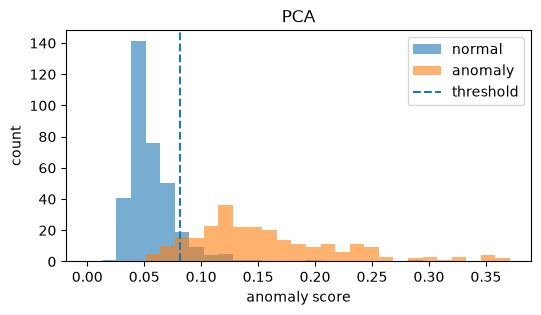

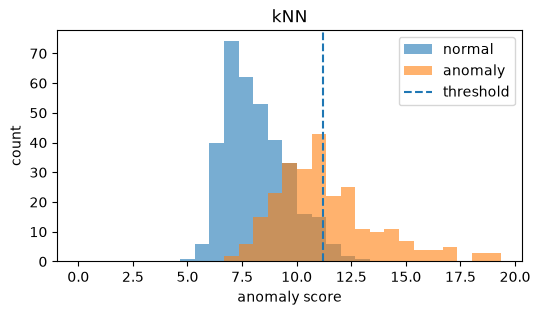

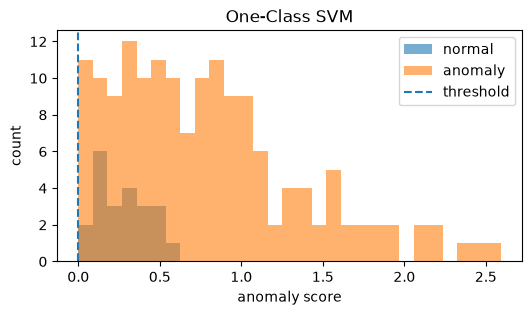

In [26]:
def plot_score_distribution(normal_score, anomaly_score, threshold, title):
    upper = np.percentile(np.r_[normal_score, anomaly_score], 99)
    bins = np.linspace(0, upper, 30)

    plt.figure(figsize=(6, 3))
    plt.hist(normal_score, bins=bins, alpha=0.6, label="normal")
    plt.hist(anomaly_score, bins=bins, alpha=0.6, label="anomaly")
    plt.axvline(threshold, linestyle="--", label="threshold")
    plt.title(title)
    plt.xlabel("anomaly score")
    plt.ylabel("count")
    plt.legend()
    plt.show()


plot_score_distribution(test_pca_score[y_test == 0], test_pca_score[y_test == 1], pca_threshold, "PCA")
plot_score_distribution(test_knn_score[y_test == 0], test_knn_score[y_test == 1], knn_threshold, "kNN")
plot_score_distribution(test_svm_score[y_test == 0], test_svm_score[y_test == 1], svm_threshold, "One-Class SVM")
